# **CAMB:** **C**ode for **A**nisotropies in the **M**icrowave **B**ackground

[Homepage de CAMB](https://camb.info)

- Código ampliamente utilizado en cosmología desarrollado por [Antony Lewis](https://inspirehep.net/authors/1000394) y [Anthony Challinor](https://inspirehep.net/authors/1031077)
- Resuelve las ecuaciones de Boltzmann y estima observables dado un set de parámetros cosmológicos.
- Cuenta con un [Python wrapper](https://camb.readthedocs.io/en/latest/), está escrito en [Fortran](https://camb.info/readme.html).
- [Paper](https://iopscience.iop.org/article/10.1086/309179) del código.

*Informacion recuperada del tutorial de Vicente Pedreros*

En caso de no tenerlo instalado hacer:

`pip install camb`
***
***

Antes de empezar CAMB, tengamos algunas consideraciones:

1. Definimos nuestro modelo cosmologico: Siguiendo a [Planck](https://arxiv.org/abs/1807.06209)

    | | |
    | - | - |
    | $H_0 = (67.4 ± 0.5) km/s/Mpc $ | Hubble constant |
    | $\Omega_m = 0.315 ± 0.0071$ | matter density parameter |
    | $\Omega_c h^2: 0.120 ± 0.0011$ | dark matter density |
    | $\Omega_b h^2 = 0.0224 ± 0.00011$ | baryon density |
    | $n_s = 0.965 ± 0.0041$ | scalar spectral index | 
    | $\tau = 0.054 ± 0.0071$ | optical depth |  
      

2. Debemos darle un modelo cosmologico a CAMB, para poder hacer predicciones. Tenemos dos formas: `camb.CAMBparams()` y `camb.set_params()`.
   ~~~
    pars = camb.CAMBparams()

    pars.set_cosmology(H0=H0, ombh2=omega_bh2, omch2=omega_ch2, tau=tau)
   ~~~

In [1]:
import numpy as np
import camb
import matplotlib.pyplot as plt
import healpy as hp

## Calcular $C_\ell$

Usando `result.get_cmb_power_spectra()` nos entrega los $C_\ell$ de las combinaciones TT, EE, BB y TE.

Estos estan indexados en un diccionario en ese mismo orden y vienen 6 tipos de $C_\ell$: { 'total', 'unlensed_scalar', 'unlensed_total', 'lensed_scalar', 'tensor', 'lens_potential' }

- total: Es el espectro completo y lenseado, incluye todo!

- unlensed_scalar: Es el espectro primordial escalar del CMB sin lensing. (sin tensores)

- lensed_scalar: Este es el mismo espectro anterior, pero incluye lensing gravitacional. (sin tensores)

- unlensed_total: Es el espectro primordial escalar del CMB sin lensing. (con tensores pero debes activarlos!!!)

Por default vienen los 4 primeros, los otros 2 es necesario activalos!

### Sin modo tensorial

En la practica, elegir modo tensorial nulo implica que los modos $B$ solo tendrán una contribución debido al lensing.

In [12]:
### Aqui no hay modo tensorial ###

#Parametros cosmologicos:
H0 = 67.4 # km/s/Mpc 
omega_m = 0.315 # parametro de densidad de materia
omega_ch2 = 0.120 # parametro de densidad de materia oscura
omega_bh2 = 0.0224 # parametro de densidad de bariones
ns = 0.965 # indice escalar espectral 
tau = 0.054 #optical depth

# Creamos un objeto donde guardaremos los parámetros cosmológicos
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0,ombh2=omega_bh2, omch2=omega_ch2, tau=tau)
pars.InitPower.set_params(ns=ns) # parametros de inflacion r, As,...

#CAMB por defecto calcula hasta l = 2500 para modificarlo se usa:
# lens_potential_accuracy regula la precision con la que se calcula el potencial de lensing
# 0 no lo calcula, 1 precision estandar y 2-3 muy preciso (mas lento).
pars.set_for_lmax(3000, lens_potential_accuracy=1)

# Ahora, para obtener resultados podemos simplemente
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, lmax= 3000, raw_cl=True)


### Plotear $C_\ell$


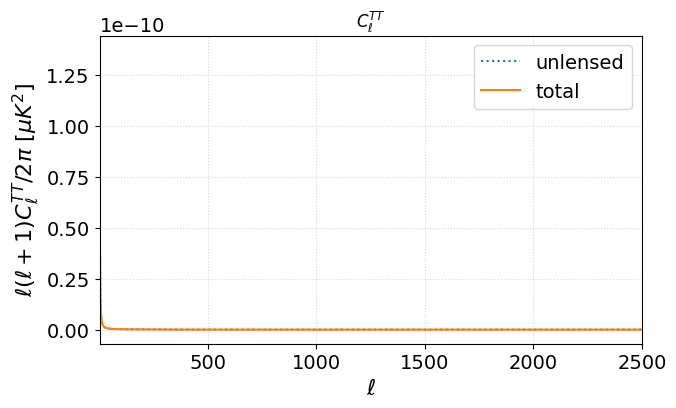

In [13]:
#llamamos los distintos Cls que nos entrega
unlensed_Cl = powers['unlensed_scalar']
total_Cl = powers['total']
lensed_Cl = powers['lensed_scalar']
unlensed_tot_Cl = powers['unlensed_total']

#crea un vector de los \ells 
vect_ells = np.arange(unlensed_Cl[:, 0].shape[0]) #le da el tamaño del Cl

factor = vect_ells*(vect_ells+1)/(2*np.pi)

#Hacemos los vectores de cada uno: 0: TT, 1: EE, 2: BB, 3: TE

vect_unlensed_Cl_TT = unlensed_Cl[:, 0]
vect_total_Cl_TT = total_Cl[:, 0]
vect_lensed_Cl_TT = lensed_Cl[:, 0]
vect_unlensed_tot_Cl_TT = unlensed_tot_Cl[:, 0]

vect_unlensed_Cl_EE = unlensed_Cl[:, 1]
vect_total_Cl_EE = total_Cl[:, 1]
vect_lensed_Cl_EE = lensed_Cl[:, 1]
vect_unlensed_tot_Cl_EE = unlensed_tot_Cl[:, 1]

vect_unlensed_Cl_BB = unlensed_Cl[:, 2]
vect_total_Cl_BB = total_Cl[:, 2]
vect_lensed_Cl_BB = lensed_Cl[:, 2]
vect_unlensed_tot_Cl_BB = unlensed_tot_Cl[:, 2]

vect_unlensed_Cl_TE = unlensed_Cl[:, 3]
vect_total_Cl_TE = total_Cl[:, 3]
vect_lensed_Cl_TE = lensed_Cl[:, 3]
vect_unlensed_tot_Cl_TE = unlensed_tot_Cl[:, 3]

#Ploteamos
#plt.figure(figsize=(7,5))
plt.plot(vect_ells, vect_unlensed_Cl_TT, label = "unlensed", linestyle=":")  
plt.plot(vect_ells, vect_total_Cl_TT, label = "total")  
# plt.plot(vect_ells, vect_lensed_Cl_TT, label = "lensed") 
# plt.plot(vect_ells, vect_unlensed_tot_Cl_TT, label = "unlensed total")   

plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$\ell(\ell+1)C_{\ell}^{TT} / 2\pi$ [$\mu K^2$]', fontsize=16)
plt.xlim(2, 2500)
plt.grid(alpha=0.5, ls=':')
plt.legend()
plt.title(r'$C_\ell^{TT}$')
plt.show()

### Con modo tensorial

Recordemos que debemos activarlos, mediante:

`pars.WantTensors = True` $ \mapsto $ Calculate tensor modes

`pars.Want_CMB_lensing = True`  $ \mapsto $ Calculate the lensing potential power spectrum



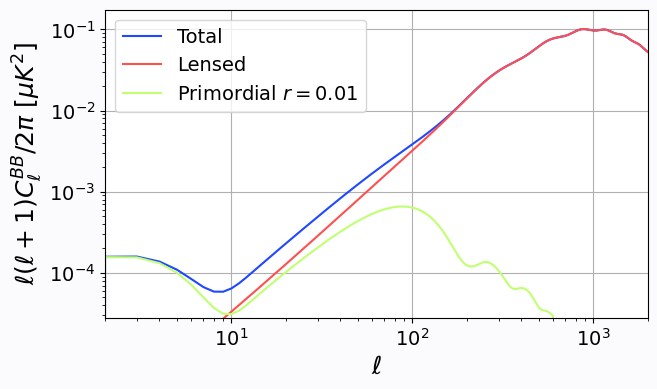

In [9]:
### Aqui hay modo tensorial ###

import plottools as pl

#Parametros cosmologicos:
H0 = 67.66 # km/s/Mpc 
omega_m = 0.315 # parametro de densidad de materia
omega_ch2 = 0.11933 # parametro de densidad de materia oscura
omega_bh2 = 0.02242 # parametro de densidad de bariones
ns = 0.9665 # indice escalar espectral 
tau = 0.0561 #optical depth
r = 0.01

# Creamos un objeto donde guardaremos los parámetros cosmológicos
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0,ombh2=omega_bh2, omch2=omega_ch2, tau=tau)
pars.InitPower.set_params(ns=ns, As = 2.105e-9, r=r) # parametros de inflacion r, As,...

# Activar tensores (IMPORTANTE)
pars.WantTensors = True
pars.Want_CMB_lensing = True


#CAMB por defecto calcula hasta l = 2500 para modificarlo se usa:
pars.set_for_lmax(3000, lens_potential_accuracy=2)

# Ahora, para obtener resultados
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, lmax= 3000, CMB_unit='muK', spectra=['total', 'lensed_scalar', 'unlensed_total', 'lens_potential'])
clphi = results.get_lens_potential_cls()

#llamamos los distintos Cls que nos entrega
lensed_Cl = powers['lensed_scalar']
total_Cl = powers['total']
unlensed_total_Cl = powers['unlensed_total']
lens_potential_Cl = powers['lens_potential']

#crea un vector de los \ells 
vect_ells = np.arange(lensed_Cl[:, 0].shape[0]) #le da el tamaño del Cl

#Ploteamos
#plt.figure(figsize=(7,5))

plt.figure(facecolor="#fbfbfe")
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=2000,xlog=True,ylog=True,grid=True,xlab=r"$\ell$",ylab=r'$\ell(\ell+1)C_{\ell}^{BB} / 2\pi$ [$\mu K^2$]') #ymin=1e-9,ymax=1e-6
plt.plot(vect_ells, total_Cl[:,2], label = "Total",color="#1f48ff")  
plt.plot(vect_ells, lensed_Cl[:,2], label = "Lensed", color="#ff5050")
plt.plot(vect_ells, unlensed_total_Cl[:,2], label = r"Primordial $r =0.01$",color="#c1ff72")  
plt.ylim(bottom=2.8e-5)
plt.legend()
plt.show()

# plt.plot(vect_ells, lens_potential_Cl[:,0]*(vect_ells*(vect_ells+1)/(2*np.pi)), label = "potencial de lensing")  
# plt.show()


# **Healpy**

[Documentacion Healpy](https://healpy.readthedocs.io/en/latest/healpy_rotator.html)

**Utilidad**:
- Convierte $C_\ell$ a mapa, asumiendo una distribución gaussiana, ie $a_{\ell ,m}(0,C_\ell)$
- Calcula Auto y Cross power spectra desde lo mapas
- Aplica transformaciones de coordenadas entre marcos de referecias Galactic, Ecliptic y Equatorial.

[TUTORIAL util de Zonca](https://www.zonca.dev/posts/2020-09-30-planck-spectra-healpy.html)

***

**Hacer mapas**:

1. Dar un semilla para la realizacion `np.random.seed()`.
2. Definir $N_{side}$ lo cual tiene estrecha relacion con el numero de pixeles, por lo que se relaciona directamente con la resolucion de los mapas. Siempre $N_{side} = 2^{n}$.
3. Definir $\ell_{max}$ en general del mismo tamaño que $C_{\ell}$. Los mapas en general reconstruyen bien hasta cierto $\ell$ en general hay confianza cuando $\ell_{max} = 2N_{side}$.
   
Probemos un poco: Distintos $N_{side}$ y veamos la diferencia en reconstrucción de $C_{\ell}$

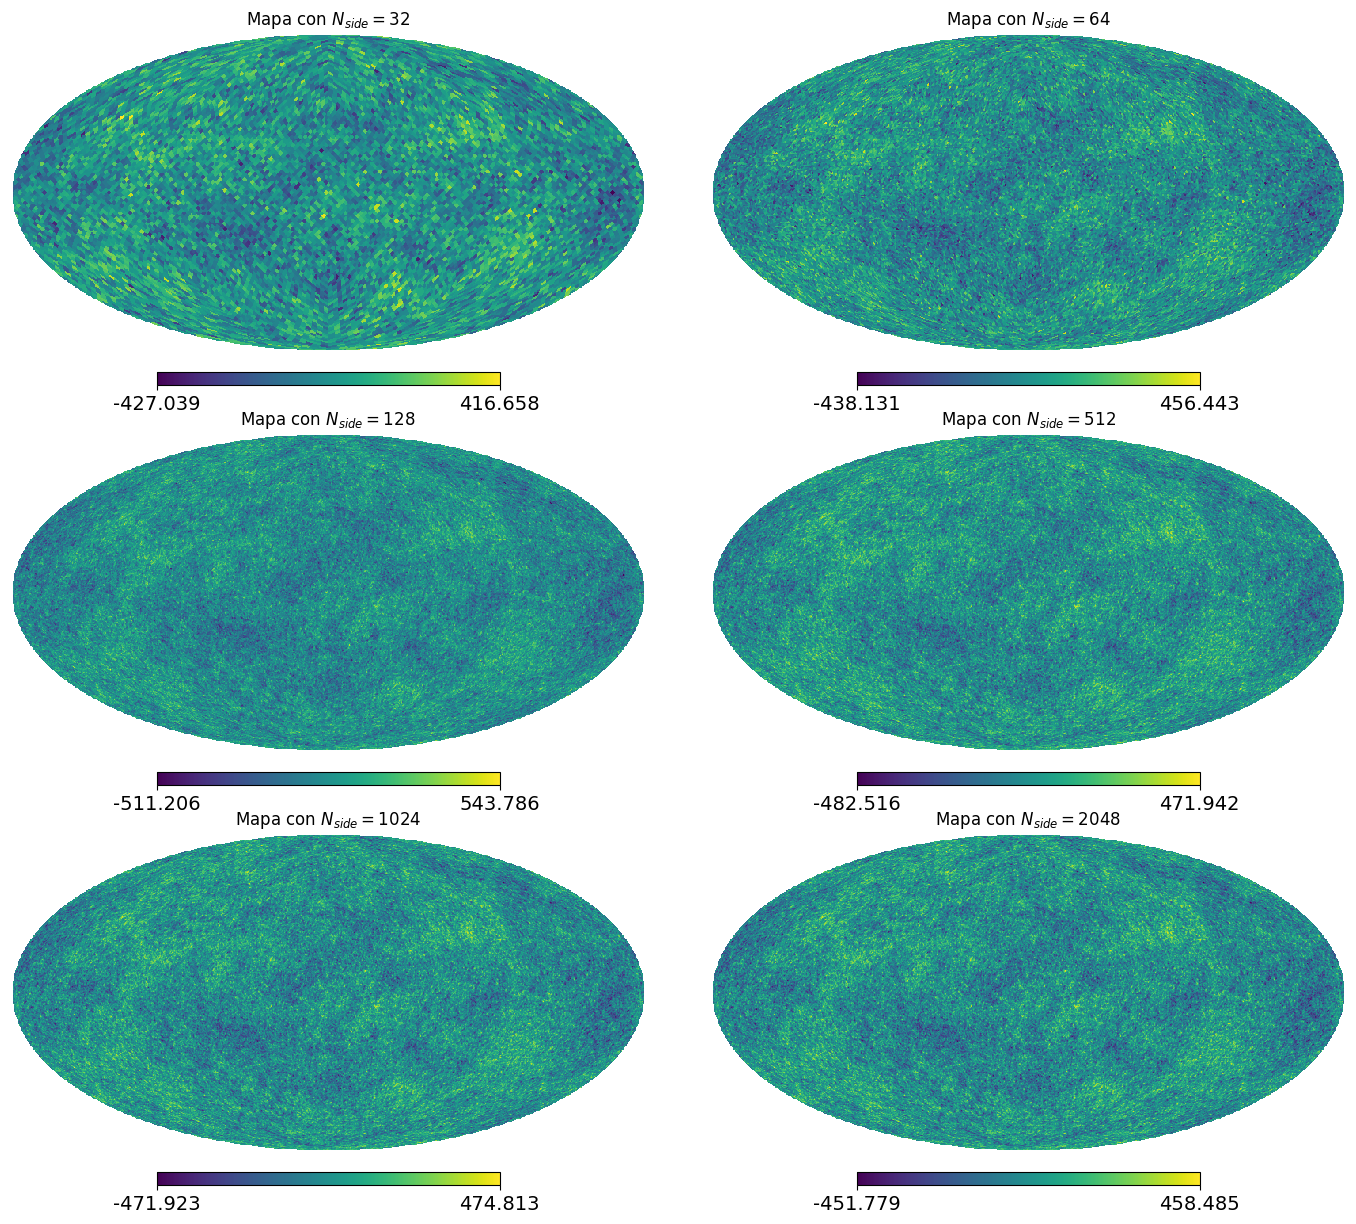

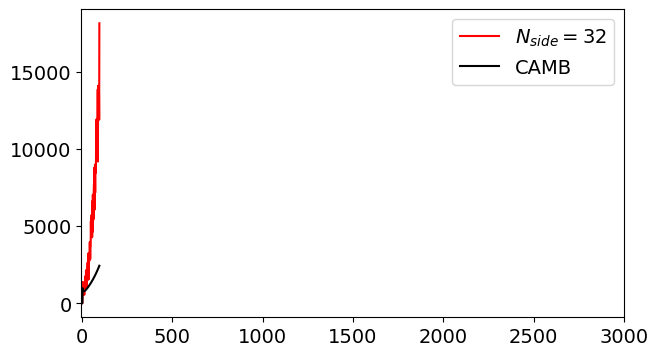

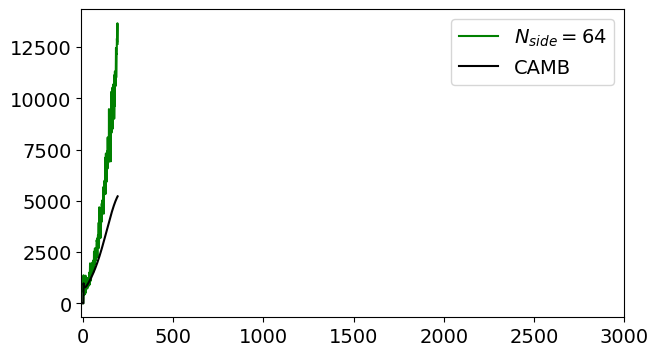

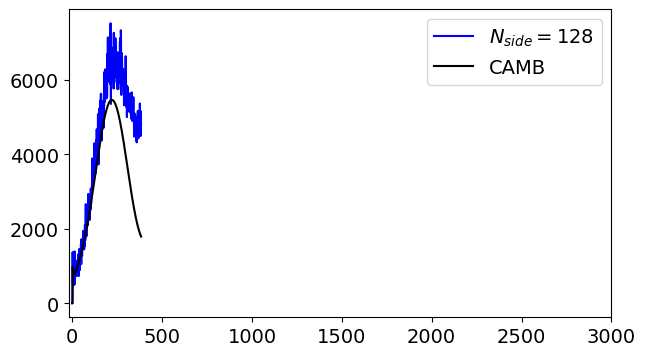

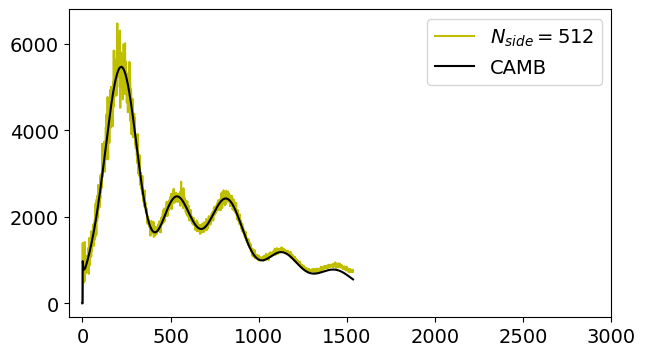

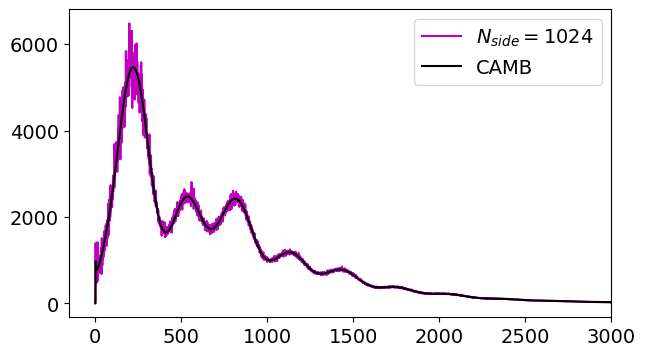

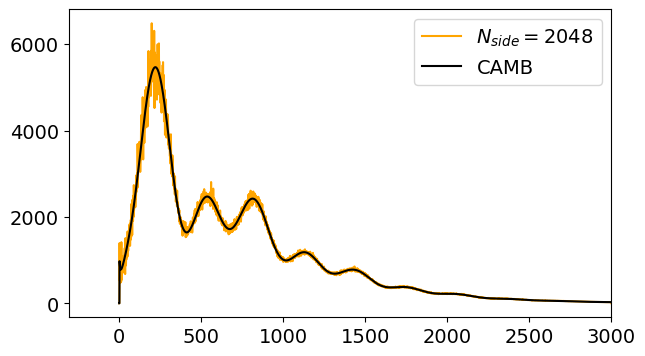

In [5]:
Nside = np.array([32, 64, 128, 512, 1024, 2048])
lmax = 3000
vect_ells = np.linspace(0, lmax, lmax + 1)

factor = (vect_ells*(vect_ells+1))/(2*np.pi)

Lmax = np.array([256, 1024, 2000, 3000])

# Los Cl deben estar sin el factor l(l+1)/2np.pi
Cl_TT_real = np.zeros_like(vect_ells)

Cl_TT_real[1:] = (2*np.pi/(vect_ells[1:]*(vect_ells[1:]+1)))* vect_total_Cl_TT[1:]

Cl_map = []
plt.figure(figsize=(14,12))
for i, nside in enumerate(Nside):

    np.random.seed(1234) #Fijamos la semilla
    map = hp.synfast(Cl_TT_real, nside=nside, lmax=lmax)

    #Calcular Cl a partir de los mapas
    Cl = hp.anafast(map)

    Cl_map.append(Cl)

    hp.mollview(map, title=rf'Mapa con $N_{{side}}={nside}$',sub=(3,2,i+1))

plt.show()

vec_color = ['r', 'g', 'b', 'y', 'm', 'orange']
for i, nside in enumerate(Nside):
    ell = np.arange(Cl_map[i].shape[0])
    end = ell[-1] + 1
    factor = (ell*(ell+1))/(2*np.pi)
    plt.plot(ell, Cl_map[i]*factor, color=vec_color[i],  label=rf'$N_{{side}}= {nside}$')
    plt.plot(vect_ells[:end], vect_total_Cl_TT[:end], color='black', label='CAMB')
    plt.legend()
    plt.xlim(right=3000)
    # plt.ylim(top=6000)
    plt.show()

# True_val = vect_total_Cl_TT != 0

**Ejercicio:** Como varian los mapas al eliminar ciertos $C_\ell$

**Ejercicio:** Crear un mapa para el potencial de lensing y usarlo para lensear los mapas T, Q y U, será igual a solo crear el mapa con los $C_\ell$ leanseados y usar el mismo seed()

deflection std is 2.65e+05 amin: this is really too high a value for something sensible


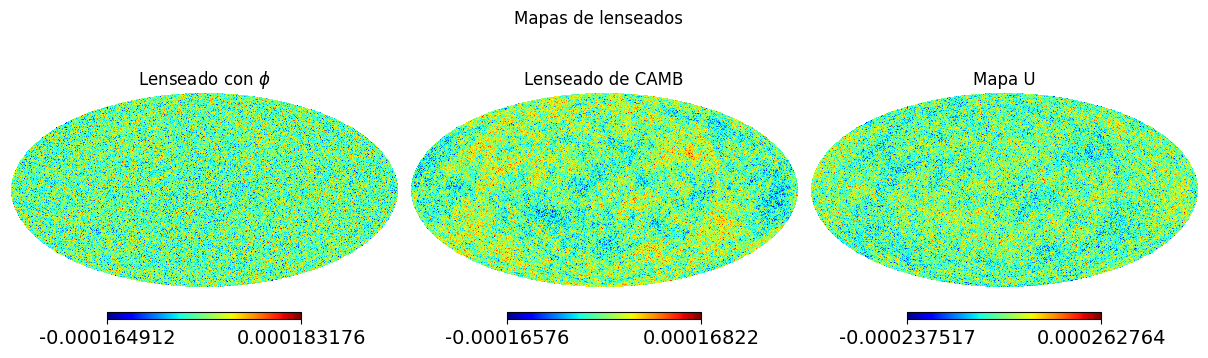

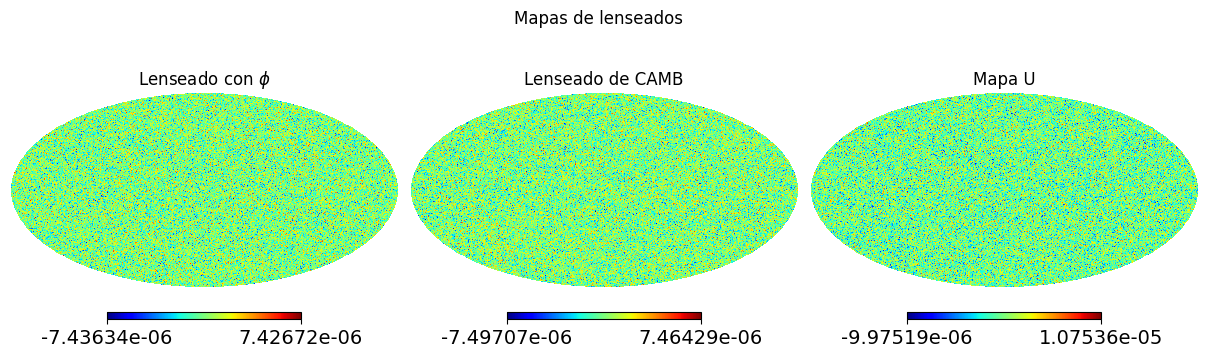

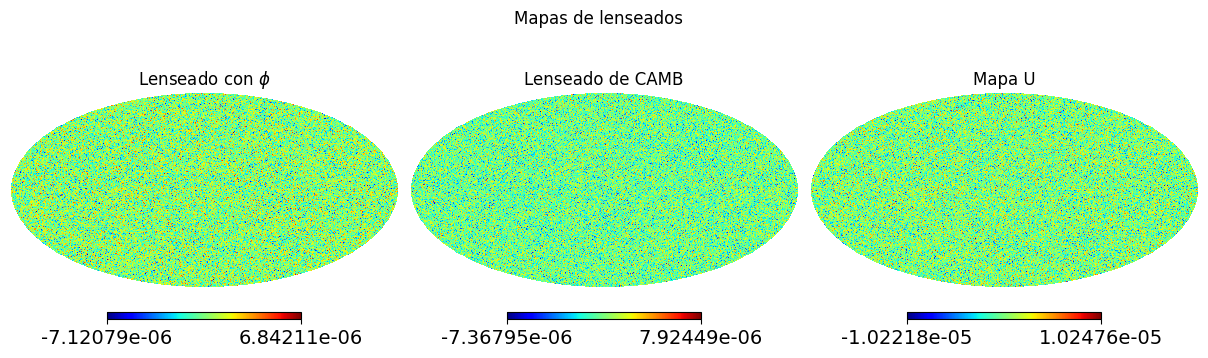

In [15]:
import lenspyx as ls

#Usaremos seed() iguales tanto para el potencial como para el mapa

np.random.seed(1234)
alm_unlensed_T, alm_unlensed_E, alm_unlensed_B = hp.synalm((unlensed_Cl[:, 0], unlensed_Cl[:, 1], unlensed_Cl[:, 2], unlensed_Cl[:, 3]), lmax=lmax, new=True)

np.random.seed(1234)
alm_phi = hp.synalm(lens_potential_Cl[:,0], lmax=lmax)

F_l = np.sqrt(vect_ells*(vect_ells+1))
dglm =  hp.almxfl(alm_phi, F_l)

T_len, Q_len, U_len = ls.alm2lenmap(
                [alm_unlensed_T, alm_unlensed_E, alm_unlensed_B],
                dlms=[dglm],  # (gradiente) ; curl omitido
                geometry=('healpix', {'nside': nside}),
                epsilon=1e-7,
                pol=True
                )


# # Pasamos los mapas a alms
# almT_len = hp.map2alm(T_len, lmax=lmax)

# almE_len, almB_len = hp.map2alm_spin([Q_len, U_len], spin=2, lmax=lmax)

# map_obs1_T, map_obs1_Q, map_obs1_U = hp.alm2map([almT_len, almE_len, almB_len], nside=nside, lmax=lmax ,pol=True)

map1 = [T_len, Q_len, U_len]
# Ahora hacemos el mapa lenseado del Cl con el efecto lensing y mismo seed()
np.random.seed(1234)
alm_lensed_T, alm_lensed_E, alm_lensed_B = hp.synalm((total_Cl[:, 0], total_Cl[:, 1], total_Cl[:, 2], total_Cl[:, 3]), lmax=lmax, new=True)


map_obs2_T, map_obs2_Q, map_obs2_U = hp.alm2map([alm_lensed_T, alm_lensed_E, alm_lensed_B], nside=nside, lmax=lmax ,pol=True)

map2 = [map_obs2_T, map_obs2_Q, map_obs2_U]

for i in np.arange(0,3):

    rest_map = map1[i] - map2[i]

    plt.figure(figsize=(12,10))
    plt.suptitle(f"Mapas de lenseados",y=0.85) 
    hp.mollview(map1[i], title=r"Lenseado con $\phi$", sub=(2,3,1), cmap = "jet")
    hp.mollview(map2[i], title=r"Lenseado de CAMB",sub=(2,3,2), cmap = "jet")
    hp.mollview(rest_map, title="Mapa U",sub=(2,3,3), cmap = "jet")
    plt.show()


In [13]:
np.arange(0,3)

array([0, 1, 2])

In [20]:
vect_ells = np.linspace(0, lmax, lmax + 1)
vect_ells[1:]

array([1.000e+00, 2.000e+00, 3.000e+00, ..., 2.998e+03, 2.999e+03,
       3.000e+03])

/tmp/ipykernel_21526/3813535433.py:4: RuntimeWarning: divide by zero encountered in divide
  Cl_TT_real = (2*np.pi/(vect_ells*(vect_ells+1)))* vect_total_Cl_TT
/tmp/ipykernel_21526/3813535433.py:4: RuntimeWarning: invalid value encountered in multiply
  Cl_TT_real = (2*np.pi/(vect_ells*(vect_ells+1)))* vect_total_Cl_TT


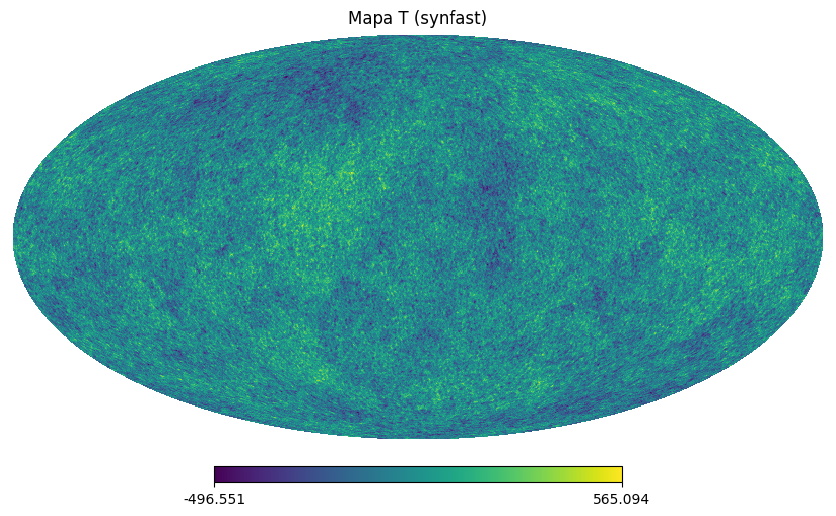

In [6]:
nside = 1024
lmax=3000

Cl_TT_real = (2*np.pi/(vect_ells*(vect_ells+1)))* vect_total_Cl_TT
Cl_TT_real[0:2]=0
# Generar mapa T
m = hp.synfast(Cl_TT_real, nside=nside, lmax=lmax)

hp.mollview(m, title="Mapa T (synfast)")

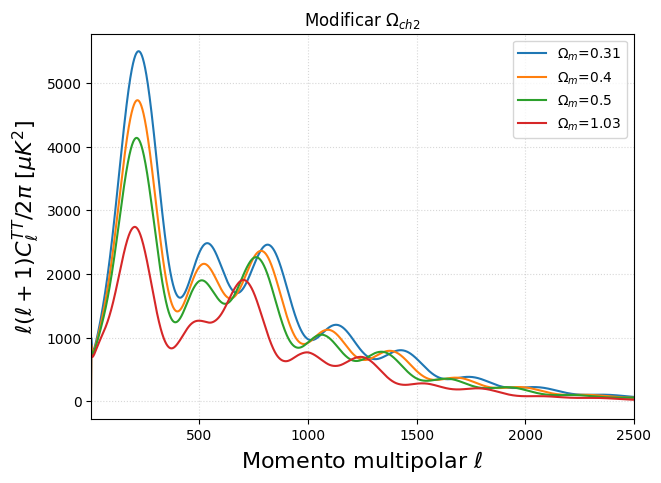

In [22]:
#Parametros cosmologicos:
H0 = 67.4 # km/s/Mpc 
omega_m = 0.315 # parametro de densidad de materia
omega_ch2 = np.array([0.120, 0.16, 0.205, 0.45]) # parametro de densidad de materia oscura
omega_bh2 = 0.0224 # parametro de densidad de bariones
ns = 0.965 # indice escalar espectral 
tau = 0.054 #optical depth

N = 4
om_m = np.zeros(N)
vect_ells =[]
vect_unlensedCL = []
for i in range(N):
    om_m[i] = (omega_bh2 + omega_ch2[i])/((H0/100)**2)

# Creamos un objeto donde guardaremos los parámetros cosmológicos
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,ombh2=omega_bh2, omch2=omega_ch2[i], tau=tau)
    pars.set_for_lmax(3000, lens_potential_accuracy=0)
    
# Ahora, para obtener resultados podemos simplemente
    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')

    unlensedCL=powers['unlensed_scalar']

    vect_ells.append(np.arange(unlensedCL[:, 0].shape[0]))
    vect_unlensedCL.append(unlensedCL[:, 0])

om_m = ((om_m*100)//1)/100
#ploteo del primer parametro:
plt.figure(figsize=(7, 5))
plt.plot(vect_ells[0], vect_unlensedCL[0], label=r'$\Omega _m$=' + f'{om_m[0]}')  # 0: TT, 1: EE, 2: BB, 3: TE
plt.plot(vect_ells[1], vect_unlensedCL[1], label=r'$\Omega _m$=' + f'{om_m[1]}')  # 0: TT, 1: EE, 2: BB, 3: TE 
plt.plot(vect_ells[2], vect_unlensedCL[2], label=r'$\Omega _m$=' + f'{om_m[2]}')  # 0: TT, 1: EE, 2: BB, 3: TE
plt.plot(vect_ells[3], vect_unlensedCL[3], label=r'$\Omega _m$=' + f'{om_m[3]}')  # 0: TT, 1: EE, 2: BB, 3: TE

plt.xlabel(r'Momento multipolar $\ell$', fontsize=16)
plt.ylabel(r'$\ell(\ell+1)C_{\ell}^{TT} / 2\pi$ [$\mu K^2$]', fontsize=16)
plt.legend()
plt.xlim(2, 2500)
plt.grid(alpha=0.5, ls=':')
plt.title(r'Modificar $ \Omega_{ch2} $')
plt.show()


- Hacer ejercicio de la profesora

- y ver como el lensing cambia los Cl como que les quita potencia

- EL POTENCIAL DE LENSING DEBE TENER VARIAS REALIZACIONES??